# Parkinson's Disease Detection — Model 2: Tuned AdaBoost
### Phase 1: Regularized Trees & Strict Leakage-Free Pipeline

---

## 1. Methodological Evolution & Architectural Design
In this phase, we address both methodological flaws of the published Bukhari & Ogudo baseline:
1. **Strict Leakage-Free Preprocessing:** The dataset is split into an 80% train and 20% test partition **prior to any SMOTE oversampling or normalization**. SMOTE is fitted strictly on training data, preventing synthetic patient features from bleeding into the test set.
2. **50-Component PCA Expansion:** Expanding PCA from 6 components to 50 components preserves **79.48% of total variance** (vs 41.82%), restoring vital high-frequency acoustic wavelets.
3. **Regularized Weak Learners:** High-dimensional data causes deep trees ($d=7$) to overfit rapidly. We constrain base tree depth to $d=4$, introduce `min_samples_split=5`, `min_samples_leaf=2`, `max_features='sqrt'`, and reduce learning rate to $\eta = 0.1$ with 300 estimators for smoother exponential loss convergence.

## 2. Environment Setup & Dependency Imports

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## 3. Dataset Ingestion

In [2]:
DATASET_PATH = 'pd_speech_features.csv'
df = pd.read_csv(DATASET_PATH, header=1)
X = df.drop(columns=['id', 'class']) if 'id' in df.columns else df.drop(columns=['class'])
y = df['class']

print(f"Total Cohort Instances: {len(df)} | Total Features: {X.shape[1]}")
print(f"Target Distribution: {y.value_counts().to_dict()}")

Total Cohort Instances: 756 | Total Features: 753
Target Distribution: {1: 564, 0: 192}


## 4. Strict Leakage-Free Pipeline (PCA=50)

In [3]:
# 1. Stratified Train-Test split FIRST
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. SMOTE fitted ONLY on training split
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_res, y_train = smote.fit_resample(X_train_raw, y_train_raw)

# 3. StandardScaler fitted ONLY on training split
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc = scaler.transform(X_test_raw)

# 4. PCA fitted ONLY on training split (50 components)
pca = PCA(n_components=50, random_state=42)
X_train = pca.fit_transform(X_train_sc)
X_test = pca.transform(X_test_sc)

var_ratio = np.sum(pca.explained_variance_ratio_)
print(f"Leakage-Controlled Partition:")
print(f"  - Training samples: {X_train.shape[0]} (Balanced {y_train.value_counts().to_dict()})")
print(f"  - Test samples: {X_test.shape[0]} (Untouched {y_test.value_counts().to_dict()})")
print(f"  - Preserved Variance with 50 PCs: {var_ratio*100:.2f}%")

Leakage-Controlled Partition:
  - Training samples: 902 (Balanced {1: 451, 0: 451})
  - Test samples: 152 (Untouched {1: 113, 0: 39})
  - Preserved Variance with 50 PCs: 79.48%


## 5. Model Architecture: Tuned Regularized AdaBoost

In [4]:
tuned_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
tuned_ada = AdaBoostClassifier(
    estimator=tuned_tree,
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)

start_time = time.time()
tuned_ada.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"Tuned AdaBoost fitted in {elapsed:.2f} seconds.")

Tuned AdaBoost fitted in 0.72 seconds.


## 6. Performance Evaluation

In [5]:
y_pred = tuned_ada.predict(X_test)
y_proba = tuned_ada.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
auc = roc_auc_score(y_test, y_proba)

metrics_df = pd.DataFrame([{
    'Model Architecture': '2. Tuned AdaBoost (PCA=50, Reg. Trees)',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1,
    'FNR': fnr,
    'AUC Score': auc
}])

display(metrics_df)
print("\nClassification Report (Unbiased Test Split):")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'PD Patient (1)']))

,Model Architecture,Accuracy,Precision,Recall,F1 Score,FNR,AUC Score
0,"2. Tuned AdaBoost (PCA=50, Reg. Trees)",0.835526,0.9,0.876106,0.887892,0.123894,0.901293



Classification Report (Unbiased Test Split):
                precision    recall  f1-score   support

   Healthy (0)       0.67      0.72      0.69        39
PD Patient (1)       0.90      0.88      0.89       113

      accuracy                           0.84       152
     macro avg       0.78      0.80      0.79       152
  weighted avg       0.84      0.84      0.84       152



## 7. Diagnostic Visualizations: Confusion Matrix, ROC & PCA Scree Plot

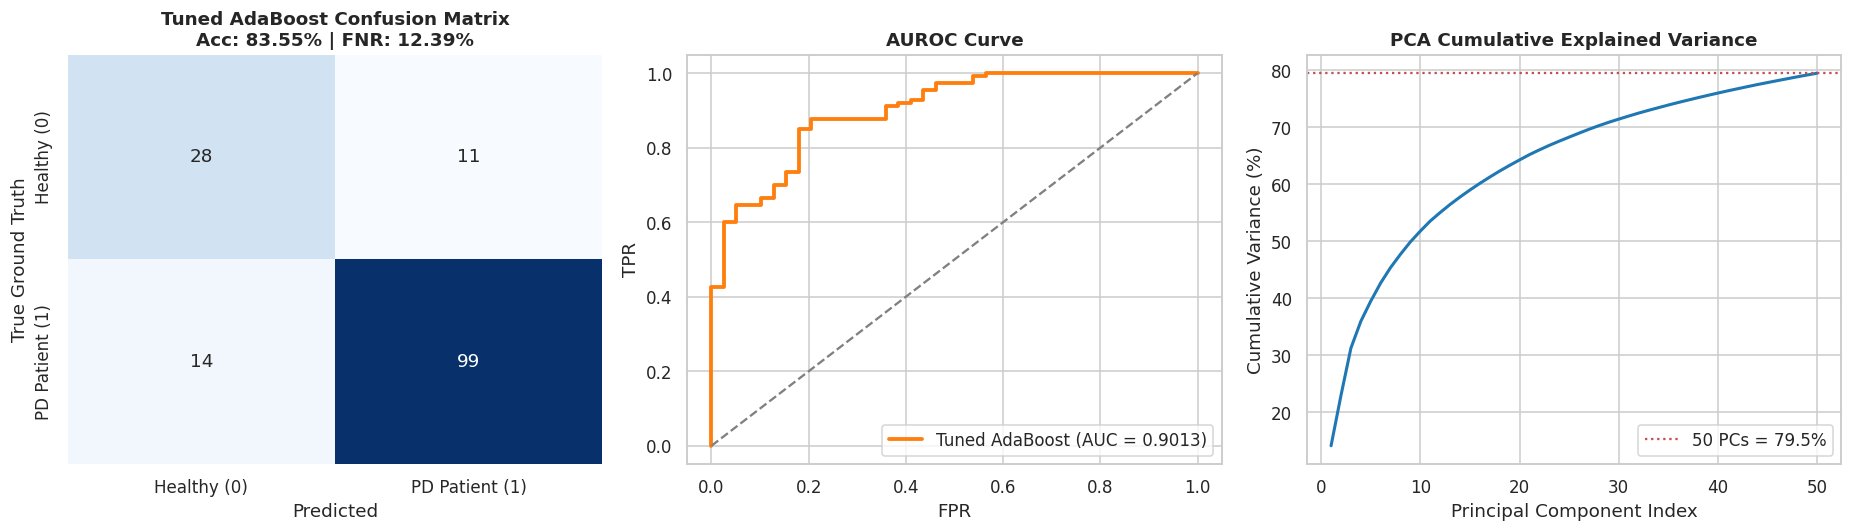

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Healthy (0)', 'PD Patient (1)'],
            yticklabels=['Healthy (0)', 'PD Patient (1)'])
axes[0].set_title(f'Tuned AdaBoost Confusion Matrix\nAcc: {acc*100:.2f}% | FNR: {fnr*100:.2f}%', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True Ground Truth')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#ff7f0e', lw=2.5, label=f'Tuned AdaBoost (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('AUROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

# Cumulative PCA Variance
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
axes[2].plot(range(1, 51), cum_var, color='#1f77b4', lw=2)
axes[2].axhline(y=var_ratio*100, color='r', linestyle=':', label=f'50 PCs = {var_ratio*100:.1f}%')
axes[2].set_title('PCA Cumulative Explained Variance', fontweight='bold')
axes[2].set_xlabel('Principal Component Index')
axes[2].set_ylabel('Cumulative Variance (%)')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 8. Clinical Findings & Next Phase Motivation
- **The Reality of Leakage-Free Benchmarks:** Eliminating synthetic data leakage reveals the true generalization baseline: **83.55% accuracy** and an FNR of **12.39%**.
- **The Tree Ensembling Plateau:** Axis-aligned orthogonal decision boundaries struggle with non-linear dysphonia feature interactions ($F_0 \times \text{shimmer} / \text{HNR}$).
- **Phase 2 Direction:** In Model 3, we project into an infinite-dimensional Hilbert space using an **RBF Support Vector Machine**.